# Analysis (Agent-based)
This notebook uses the aggregated output of `X1_data.ipynb`

In [2]:
import json
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import polars as pl
from r_utils import fit_lmer_full
from plot_utils import _configure_fonts, plot_emmeans_grouped_bar, SETTING_COLOR, SETTING_MAP, GRAPH_MAP, SETTING_MARKER, OKABE_ITO
import matplotlib.pyplot as plt


_configure_fonts()
# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))



Error importing in API mode: ImportError("dlopen(/Users/gs/Documents/GitHub/llm-debate-sim/.venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <85D47EFD-9B5F-368A-BC00-EBCFE4080F31> /Users/gs/Documents/GitHub/llm-debate-sim/.venv/lib/python3.12/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [3]:
ROLE_TO_IDX = {
    "Strategic Planner": 0,
    "Language Mediator": 1,
    "Online Friend": 2,
    "Software Engineer": 3,
    "Academic Scholar": 4,
    "Chemist": 5,
    "Human Participant": 6,
    "LLM": 7,
    "Cybersecurity Analyst": 8,
    "Mathematician": 9,
    "Storyteller": 10,
    "Clinical Physician": 11,
    "Biomedical Researcher": 12,
    "Financial Analyst": 13,
    "Lexicographer": 14,
    "Assistant": 15,
}

MATCHES = [
    ("llama-doc", "Clinical Physician"),
    ("llama-base", "LLM"),
    ("llama-base", "Human Participant"),
    ("llama-assistant", "Assistant"),
    ("llama-biomed", "Biomedical Researcher"),
    ("llama-chemist", "Chemist"),
    ("llama-coder", "Software Engineer"),
    ("llama-cyber", "Cybersecurity Analyst"),
    ("llama-finance", "Financial Analyst"),
    ("llama-hermes", "Strategic Planner"),
    ("llama-openmath", "Mathematician"),
    ("llama-lexicographer", "Lexicographer"),
    ("llama-linguist", "Language Mediator"),
    ("llama-roleplay", "Storyteller"),
    ("llama-scholar", "Academic Scholar"),
    ("llama-user", "Online Friend"),
]

def save_model_results(results_dict: dict, name: str, save_path: Path):
    '''
    Save results to CSV or JSON files in a structured directory (from fit_lmer_full)
    '''
    save_path = save_path / f"{name}"
    save_path.mkdir(parents=True, exist_ok=True)
    for key, df in results_dict.items():
        if isinstance(df, pd.DataFrame):
            df.to_csv(save_path / f"{key}.csv", index=True)
        else:
            with open(save_path / f"{key}.json", "w") as f:
                json.dump(df, f, indent=4)


In [4]:
data_path = Path.cwd().parent / "data" / "outputs" / "aggregated"
result_path = Path.cwd().parent / "data" / "analysis" 
result_path.mkdir(parents=True, exist_ok=True)


agg_path = result_path / "aggregated" / "agent"
cts_path = result_path / "contrasts" / "agent"
con_path = result_path / "continuous" / "agent"

agg_path.mkdir(parents=True, exist_ok=True)
cts_path.mkdir(parents=True, exist_ok=True)
con_path.mkdir(parents=True, exist_ok=True)

lfs = pl.read_parquet(data_path / "agent_level_data.parquet")
lfs.sample(10, seed=0)

agent_id,plasticity_tv,plasticity_true,plasticity_false,plasticity_neither,plasticity_tv_1,net_change,net_gain,progress_ratio,progress_forward,progress_backward,progress_efficiency,monotonicity,agent_accuracy,agent_error,T,is_matched,is_expert,statement_id,degree,role,model,setting,seed,graph_seed,graph_id,graph_type,centrality,influence_out,influence_in,influence_out_dir,influence_in_dir,effective_n_out,effective_n_in,net_uncertain,monotonicity_uncertainty,degree_z,centrality_z,agent_configs,run_id
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,bool,bool,cat,f64,cat,cat,cat,i64,cat,str,cat,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,cat
18,0.001381,0.000509,0.001172,0.001081,0.000855,0.004061,0.003906,0.333333,0.0078125,0.003906,0.4,0.294079,0.994141,0.005859,10,false,false,"""false_4""",16.0,"""Assistant""","""llama-base""","""random_roles""",814183,"""2012155723""","""erdos-renyi-814183""","""erdos-renyi""",0.181388,0.002811,0.000855,0.334995,-0.14862,21.084433,35.024387,0.004061,0.375627,1.203666,1.386628,"""base""","""random_roles:erdos-renyi-81418…"
9,0.036123,0.035986,0.034043,0.002217,0.039302,0.326931,0.32666,0.907734,0.343262,0.016602,0.979502,0.905044,0.993164,0.006836,10,false,false,"""true_1""",16.0,"""Storyteller""","""llama-base""","""random_roles""",1170252924,"""2292123236""","""erdos-renyi-1170252924""","""erdos-renyi""",0.154152,0.110894,0.039302,-0.532179,0.613845,4.470789,13.609891,0.326931,14.747716,1.203666,0.44143,"""base""","""random_roles:erdos-renyi-11702…"
12,0.066518,0.066089,0.065862,0.001086,0.000994,0.655066,0.655029,0.991134,0.657959,0.00293,0.989672,0.984791,0.993164,0.006836,10,true,false,"""true_1""",8.0,"""LLM""","""llama-base""","""random_roles""",900911955,"""395036430""","""watts-strogatz-900911955""","""watts-strogatz""",0.155701,0.005155,0.000994,0.930333,-0.047712,3.026728,11.256805,0.655066,60.343866,-0.786464,0.495189,"""base""","""random_roles:watts-strogatz-90…"
31,0.005618,0.003601,0.005615,0.002019,0.0,0.056175,0.056152,1.0,0.056152,-0.0,0.672515,1.0,0.972656,0.027344,10,true,false,"""false_0""",13.0,"""LLM""","""llama-base""","""base_llms""",597409993,"""3798279163""","""erdos-renyi-597409993""","""erdos-renyi""",0.115967,0.0,0.0,0.0,0.0,0.0,0.0,0.056175,2.782691,0.457367,-0.883721,"""base""","""base_llms:erdos-renyi-59740999…"
42,0.003908,0.003174,0.00193,0.002712,0.003255,0.010572,0.010254,0.323077,0.020996,0.010742,0.466667,0.270521,0.988281,0.011719,10,false,false,"""true_8""",20.0,"""Assistant""","""llama-base""","""random_roles""",1265438423,"""2701326989""","""erdos-renyi-1265438423""","""erdos-renyi""",0.186899,0.003767,0.003255,0.092469,0.312653,14.271843,28.80638,0.010572,0.389829,2.198731,1.577879,"""base""","""random_roles:erdos-renyi-12654…"
15,0.000767,0.000367,0.000781,0.000386,0.0,0.007675,0.0078125,1.0,0.0078125,-0.0,0.571429,1.0,0.994141,0.005859,10,true,false,"""false_4""",8.0,"""LLM""","""llama-base""","""base_llms""",473392625,"""3830640276""","""watts-strogatz-473392625""","""watts-strogatz""",0.154475,0.0,0.0,0.0,0.0,0.0,0.0,0.007675,1.986363,-0.786464,0.452636,"""base""","""base_llms:watts-strogatz-47339…"
10,0.151532,0.115251,0.150733,0.037079,0.160869,0.092703,-0.076855,-0.066685,0.537827,0.614681,-0.400163,0.061177,0.115204,0.884796,10,true,true,"""true_6""",11.0,"""Academic Scholar""","""llama-scholar""","""experts""",814183,"""1769674741""","""watts-strogatz-814183""","""watts-strogatz""",0.215952,0.115363,0.160869,-0.000974,0.114208,22.041055,21.409377,0.092703,0.250014,-0.040165,2.586133,"""expert_matched""","""experts:watts-strogatz-814183:…"
10,0.048367,0.039685,0.038784,0.018265,0.048369,0.100569,0.100569,0.259307,0.244205,0.143635,0.30102,0.207929,0.766474,0.233526,10,true,true,"""false_4""",9.0,"""Academic Scholar""","""llama-scholar""","""experts""",1170252924,"""365860106""","""watts-strogatz-1170252924""","""watts-strogatz""",0.182458,0.071948,0.048369,0.0175,0.09779,13.559916,13.419152,0.100569,0.55061,-0.537698,1.423

In [5]:
dft = lfs.to_pandas()
dft['setting'] = pd.Categorical(
    dft['setting'], 
    categories=["base_llms", "random_roles", "random_experts", "experts"], 
    ordered=False 
)
dft['model'] = pd.Categorical(dft['model'], 
                              categories=sorted(dft['model'].unique()), 
                              ordered=False)
dft['graph_type'] = pd.Categorical(dft['graph_type'],
                                  categories=sorted(dft['graph_type'].unique()),
                                  ordered=False)
dft['role'] = pd.Categorical(dft['role'],
                                  categories=sorted(dft['role'].unique()),
                                  ordered=False)
dft['statement_id'] = pd.Categorical(dft['statement_id'],
                                  categories=sorted(dft['statement_id'].unique()),
                                  ordered=False)
dft['graph_seed'] = pd.Categorical(dft['graph_seed'],
                                  categories=sorted(dft['graph_seed'].unique()),
                                  ordered=False)
# Specification of whether agent is a generalist, an expert in a mismatched role, or an expert in a matched role
dft['agent_configs'] = np.select(
    [
        ~dft['is_expert'],
        dft['is_expert'] & ~dft['is_matched'],
        dft['is_expert'] & dft['is_matched'],
    ],
    ['base', 'expert_mismatched', 'expert_matched'],
    default='base'
)

dft['run_id'] = (
    dft['setting'].astype(str) + ':' +
    dft['graph_id'].astype(str) + ':' +
    dft['statement_id'].astype(str)
)
dft['run_id'] = pd.Categorical(dft['run_id'], categories=sorted(dft['run_id'].unique()))

dft.columns


Index(['agent_id', 'plasticity_tv', 'plasticity_true', 'plasticity_false',
       'plasticity_neither', 'plasticity_tv_1', 'net_change', 'net_gain',
       'progress_ratio', 'progress_forward', 'progress_backward',
       'progress_efficiency', 'monotonicity', 'agent_accuracy', 'agent_error',
       'T', 'is_matched', 'is_expert', 'statement_id', 'degree', 'role',
       'model', 'setting', 'seed', 'graph_seed', 'graph_id', 'graph_type',
       'centrality', 'influence_out', 'influence_in', 'influence_out_dir',
       'influence_in_dir', 'effective_n_out', 'effective_n_in',
       'net_uncertain', 'monotonicity_uncertainty', 'degree_z', 'centrality_z',
       'agent_configs', 'run_id'],
      dtype='str')

# Mixed-Effects Models / Aggregates

**Note on clustering structure**

For a given setting, role assignments and adjacency matrices are fixed across statements. Specifically, for any given `(graph_type, seed)` pair, the network topology and role assignments are identical regardless of which statement is being discussed. This creates two non-independent dimensions in our data:

1. **Agents within the same `(graph_type, seed)` are not independent** — they share the same network structure and role assignments.
2. **The same agent-network configuration is reused across statements** — so observations from the same `(graph_type, seed)` pair but different statements are also not independent.

This means errors should be clustered by either `statement_id` or `(graph_type, seed)` — but not both simultaneously in a single-grouping estimator like `statsmodels` MixedLM. The right choice depends on which source of dependence is larger in practice, or we use crossed random effects `(1 | statement_id) + (1 | graph_type:seed)` via `pymer4`/`lme4`.

##### How to install `R` and depenpencies on Macs?
1. Go to https://cran.r-project.org/bin/macosx/ and download the `R-4.5.x-arm64.pkg` installer. 
2. Run it: this installs `R` to `/Library/Frameworks/R.framework/` where `rpy2` expects it.
3. Run `Rscript -e 'install.packages(c("nloptr", "lme4", "lmerTest"), repos="https://cran.r-project.org")`
4. Install `rpy2` via `uv add rpy2`
#### Install additional packages
1. `Rscript -e 'install.packages("emmeans", repos="https://cran.r-project.org")'`
2. `Rscript -e 'install.packages("pbkrtest", repos="https://cran.r-project.org")'`
3. `Rscript -e 'install.packages("RLRsim", repos="https://cran.r-project.org")'`

## 1. Aggregated Stats

In [6]:
COL_PRETTY_NAMES = {
    # "influence_in": "Incoming Influence (Magnitude)",
    # "influence_out": "Outgoing Influence (Magnitude)",
    # "influence_in_dir": "Incoming Influence (Direction)",
    "influence_out": "Influence",
    "plasticity_tv": "Plasticity",
    # "plasticity_tv_1": "Plasticity (without baseline)",
    # "plasticity_false": "Plasticity (False)",
    # "plasticity_true": "Plasticity (True)",
    # "plasticity_neither": "Plasticity (Uncertain)",
    "monotonicity": "Directedness",
    # 'net_change': 'Net Drift',
    # 'net_gain': 'Net Gain to Truth',
    # 'progress_efficiency': 'Progress Efficiency',
    # 'net_drift': 'Net Drift towards Correct',
    # 'agent_accuracy': 'Agent Accuracy',
    # 'agent_error': 'Agent Error',
    # 'progress_ratio': 'Progress Ratio',
    # 'progress_forward': 'Drift to Truth',
    # 'progress_backward': 'Drift away from Truth',
}

INFO:root:Coefficients extracted successfully.
INFO:root:ANOVA table extracted successfully.
INFO:root:EMMs extracted successfully.
INFO:root:Fit statistics extracted successfully.
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern pruned
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:Zapf dropped
INFO:fontTools.subset:feat dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:morx dropped
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'glyf': 43 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'B', 'E', 'G', 'I', 'L', 'M', 'R', 'S', 'V', 'W', 'a', 'c', 'd', 'e', 'eacute', 'f', 'five', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'ohungarumlaut', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'space', 't', 'u', 'x', 'y', 'z', 'zero']
INFO:fo

Finished fitting model for influence_out with setting * graph_type
Saved figure to: /Users/gs/Documents/GitHub/llm-debate-sim/data/analysis/aggregated/agent/influence_out_grouped_bar.pdf


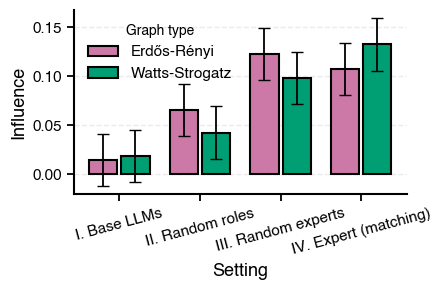

INFO:root:Coefficients extracted successfully.
INFO:root:ANOVA table extracted successfully.
INFO:root:EMMs extracted successfully.
INFO:root:Fit statistics extracted successfully.
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern pruned
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:Zapf dropped
INFO:fontTools.subset:feat dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:morx dropped
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'glyf': 42 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'B', 'E', 'G', 'I', 'L', 'M', 'P', 'R', 'S', 'V', 'W', 'a', 'c', 'd', 'e', 'eacute', 'five', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'ohungarumlaut', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'space', 't', 'x', 'y', 'z', 'zero']
INFO:fontToo

Finished fitting model for plasticity_tv with setting * graph_type
Saved figure to: /Users/gs/Documents/GitHub/llm-debate-sim/data/analysis/aggregated/agent/plasticity_tv_grouped_bar.pdf


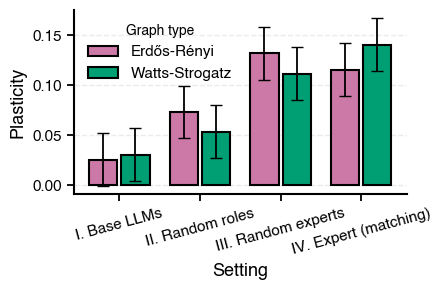

INFO:root:Coefficients extracted successfully.
INFO:root:ANOVA table extracted successfully.
INFO:root:EMMs extracted successfully.
INFO:root:Fit statistics extracted successfully.
INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern pruned
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:Zapf dropped
INFO:fontTools.subset:feat dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:morx dropped
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'glyf': 45 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'B', 'D', 'E', 'G', 'I', 'L', 'M', 'R', 'S', 'V', 'W', 'a', 'c', 'd', 'e', 'eacute', 'eight', 'four', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'ohungarumlaut', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'six', 'space', 't', 'two', 'x', 'y', 'z

Finished fitting model for monotonicity with setting * graph_type
Saved figure to: /Users/gs/Documents/GitHub/llm-debate-sim/data/analysis/aggregated/agent/monotonicity_grouped_bar.pdf


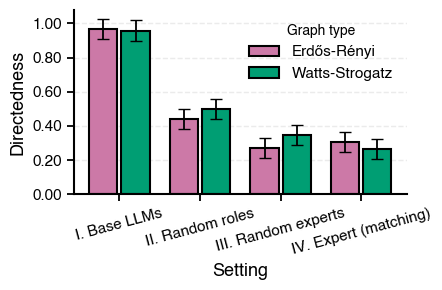

In [7]:
for col in COL_PRETTY_NAMES.keys():
    var_name = col
    res = fit_lmer_full(
    df=dft,
    specification=f'''
        {var_name} ~ setting * graph_type + 
        (1 | statement_id) + 
        (1 | graph_type:graph_seed)
    ''',
    emm_formula='~setting * graph_type',
    reml=True,  
    # lmer_df="kenward-roger",
)
    save_model_results(res, f"{var_name}_setting_graph_type", agg_path)
    print(f"Finished fitting model for {var_name} with setting * graph_type")
    fig, ax, emm_plot = plot_emmeans_grouped_bar(
        emm_df=res["emm"],
        setting_reference=dft if "dft" in globals() else None,
        y_label=f"{COL_PRETTY_NAMES.get(var_name, var_name)}",
        title="",
        figsize=(4.5, 3),
        show=True,
        out_fig=agg_path / f"{var_name}_grouped_bar.pdf",
    )

## 2. Influence and Persistence

In [7]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import pandas as pd


def fit_lmer_with_icc(
    df: pd.DataFrame,
    specification: str,
    reml: bool = True,
) -> dict:
    """Fit lmer and extract variance components + ICC for agent_id:graph_id."""
    with (ro.default_converter + pandas2ri.converter).context():
        ro.globalenv["df"] = ro.conversion.py2rpy(df)
        ro.globalenv["spec"] = specification
        ro.globalenv["use_reml"] = reml

        ro.r('''
            library(lmerTest)
            df_model <- lmerTest::lmer(as.formula(spec), data = df, REML = use_reml)

            # Point estimates
            vc <- as.data.frame(VarCorr(df_model))
            sigma_agent <- vc[vc$grp == "agent_id:graph_id", "vcov"]
            sigma_graph <- vc[vc$grp == "graph_id", "vcov"]
            sigma_stmt  <- vc[vc$grp == "statement_id", "vcov"]
            sigma_resid <- vc[vc$grp == "Residual", "vcov"]
            sigma_total <- sigma_agent + sigma_graph + sigma_stmt + sigma_resid

            # Parametric bootstrap for ICC CIs
            icc_fn <- function(fit) {
                vc <- as.data.frame(VarCorr(fit))
                sa <- vc[vc$grp == "agent_id:graph_id", "vcov"]
                sg <- vc[vc$grp == "graph_id", "vcov"]
                ss <- vc[vc$grp == "statement_id", "vcov"]
                sr <- vc[vc$grp == "Residual", "vcov"]
                st <- sa + sg + ss + sr
                c(icc_agent = sa/st, icc_graph = sg/st,
                icc_stmt = ss/st, icc_resid = sr/st)
            }

            boot_result <- bootMer(df_model, FUN = icc_fn, nsim = 200,
                                    type = "parametric", use.u = FALSE)

            # Extract 2.5 / 97.5 percentiles per ICC component
            boot_ci <- apply(boot_result$t, 2, quantile,
                            probs = c(0.025, 0.975), na.rm = TRUE)

            icc_df <- data.frame(
                icc_agent = sigma_agent / sigma_total,
                icc_graph = sigma_graph / sigma_total,
                icc_stmt  = sigma_stmt  / sigma_total,
                icc_resid = sigma_resid / sigma_total,
                var_agent = sigma_agent,
                var_graph = sigma_graph,
                var_stmt  = sigma_stmt,
                var_resid = sigma_resid,
                icc_agent_lo = boot_ci[1, "icc_agent"],
                icc_agent_hi = boot_ci[2, "icc_agent"],
                icc_graph_lo = boot_ci[1, "icc_graph"],
                icc_graph_hi = boot_ci[2, "icc_graph"],
                icc_stmt_lo  = boot_ci[1, "icc_stmt"],
                icc_stmt_hi  = boot_ci[2, "icc_stmt"],
                icc_resid_lo = boot_ci[1, "icc_resid"],
                icc_resid_hi = boot_ci[2, "icc_resid"]
            )
        ''')

        return {
            "vc":  ro.conversion.rpy2py(ro.r("vc")),
            "icc": ro.conversion.rpy2py(ro.r("icc_df")),
        }
        
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
import pandas as pd


def lrt_agent_variance(df: pd.DataFrame) -> dict:
    """Exact restricted LRT for the agent_id:graph_id variance component."""
    with (ro.default_converter + pandas2ri.converter).context():
        ro.globalenv["df"] = ro.conversion.py2rpy(df)

        ro.r('''
            library(lme4)
            library(RLRsim)

            # Full model with the random effect to be tested
            m_full <- lmer(
                influence_out ~ 1 + (1 | graph_id) + (1 | statement_id) + (1 | agent_id:graph_id),
                data = df, REML = TRUE
            )

            # Reduced model: without the agent random effect
            m_reduced <- lmer(
                influence_out ~ 1 + (1 | graph_id) + (1 | statement_id),
                data = df, REML = TRUE
            )

            # Model containing ONLY the random effect being tested
            m_alt <- lmer(
                influence_out ~ 1 + (1 | agent_id:graph_id),
                data = df, REML = TRUE
            )

            # Exact RLRT
            test <- exactRLRT(m = m_alt, mA = m_full, m0 = m_reduced, nsim = 10000)

            lrt_stat <- as.numeric(test$statistic)
            lrt_p    <- as.numeric(test$p.value)
        ''')

        return {
            "lrt_stat": float(ro.r("lrt_stat")[0]),
            "lrt_p":    float(ro.r("lrt_p")[0]),
        }

In [10]:
icc_results = []
for setting in dft['setting'].unique():
    sub = dft[dft['setting'] == setting].copy()
    res = fit_lmer_with_icc(
        sub,
        # specification="influence_out ~ graph_type + (1 | graph_id) + (1 | agent_id:graph_id) + (1 | statement_id)",
        specification="influence_out ~ 1 +  (1 | graph_id) + (1 | statement_id) + (1 | agent_id:graph_id)",
    )
    lrt_res = lrt_agent_variance(sub)

    icc_row = res["icc"].iloc[0].to_dict()
    icc_row["setting"] = setting
    icc_row["lrt_stat"] = lrt_res["lrt_stat"]
    icc_row["lrt_p"] = lrt_res["lrt_p"]
    icc_results.append(icc_row)

icc_df = pd.DataFrame(icc_results)
print(icc_df[["setting", "icc_agent", "icc_graph", "icc_stmt", "icc_resid"]])

          setting  icc_agent  icc_graph  icc_stmt  icc_resid
0       base_llms   0.000000   0.004248  0.899966   0.095786
1    random_roles   0.000000   0.019500  0.756009   0.224491
2  random_experts   0.041499   0.059943  0.548458   0.350100
3         experts   0.021843   0.042353  0.593634   0.342171


In [11]:
icc_df.to_csv(agg_path / "influence_out_icc.csv", index=False)
icc_df[['setting','icc_agent', 'icc_agent_lo', 'icc_agent_hi', 'icc_graph', 'icc_graph_lo', 'icc_graph_hi', 'lrt_p']]

,setting,icc_agent,icc_agent_lo,icc_agent_hi,icc_graph,icc_graph_lo,icc_graph_hi,lrt_p
0,base_llms,0.000000,0.000000,0.000503,0.004248,0.001838,0.009781,1.0
1,random_roles,0.000000,0.000000,0.001465,0.019500,0.008011,0.040886,1.0
2,random_experts,0.041499,0.030520,0.058875,0.059943,0.021166,0.108106,0.0
3,experts,0.021843,0.014612,0.031762,0.042353,0.018287,0.082430,0.0


In [9]:
def plot_icc_grouped_bar(
    icc_df: pd.DataFrame,
    setting_reference: pd.DataFrame | None = None,
    out_fig: Path | None = None,
    title: str = "",
    y_label: str = "Intraclass correlation (ICC, %)",
    figsize: tuple[float, float] = (4.5, 3.5),
    show: bool = True,
):
    """Plot grouped ICC bars (agent vs graph) with asymmetric CIs."""
    from matplotlib.ticker import PercentFormatter

    _configure_fonts()

    required_cols = {
        "setting",
        "icc_agent", "icc_agent_lo", "icc_agent_hi",
        "icc_graph", "icc_graph_lo", "icc_graph_hi",
    }
    missing = required_cols.difference(set(icc_df.columns))
    if missing:
        raise ValueError(f"Missing required columns in icc_df: {sorted(missing)}")

    plot_df = icc_df.copy()
    plot_df["setting"] = plot_df["setting"].astype(str)

    if setting_reference is not None and "setting" in setting_reference.columns:
        setting_order = [
            s for s in setting_reference["setting"].astype(str).dropna().unique()
            if s in set(plot_df["setting"])
        ]
    else:
        setting_order = [
            s for s in ["base_llms", "random_roles", "random_experts", "experts"]
            if s in set(plot_df["setting"])
        ]
    if not setting_order:
        setting_order = sorted(plot_df["setting"].unique())

    component_order = ["icc_agent", "icc_graph"]
    component_labels = {
        "icc_agent": "Within-agent",
        "icc_graph": "Between-network",
    }

    pivot_mean = (
        plot_df.set_index("setting")[component_order]
        .reindex(setting_order)
        .astype(float)
    )
    pivot_lcl = (
        plot_df.set_index("setting")[["icc_agent_lo", "icc_graph_lo"]]
        .rename(columns={"icc_agent_lo": "icc_agent", "icc_graph_lo": "icc_graph"})
        .reindex(setting_order)
        .astype(float)
    )
    pivot_ucl = (
        plot_df.set_index("setting")[["icc_agent_hi", "icc_graph_hi"]]
        .rename(columns={"icc_agent_hi": "icc_agent", "icc_graph_hi": "icc_graph"})
        .reindex(setting_order)
        .astype(float)
    )

    x = np.arange(len(setting_order))
    width = 0.4

    colors = [OKABE_ITO["sky"], OKABE_ITO["vermilion"]]
    ci_color = OKABE_ITO["black"]

    fig, ax = plt.subplots(figsize=figsize)
    for j, comp in enumerate(component_order):
        y = pivot_mean[comp].to_numpy()
        yerr_lower = y - pivot_lcl[comp].to_numpy()
        yerr_upper = pivot_ucl[comp].to_numpy() - y

        xpos = x + (j - 0.5) * width
        ax.bar(
            xpos,
            y,
            width=width - 0.05,
            label=component_labels[comp],
            color=colors[j % len(colors)],
            edgecolor=ci_color,
            linewidth=1.5,
            yerr=np.vstack([yerr_lower, yerr_upper]),
            capsize=4,
            error_kw={"elinewidth": 1.3, "ecolor": ci_color},
            alpha=0.95,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([SETTING_MAP.get(s, s) for s in setting_order], rotation=15, ha="center")
    ax.set_xlabel("Setting")
    ax.set_ylabel(y_label)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.set_title(title)
    ax.legend(frameon=False, loc="upper left")
    ax.grid(axis="y", alpha=0.25, linestyle="--", linewidth=1)
    ax.set_axisbelow(True)
    
    

    y_top = float(np.nanmax(pivot_ucl.to_numpy()))
    ax.set_ylim(0, max(0.05, y_top * 1.15))

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)
    ax.tick_params(width=1.3, length=5)
    plt.tight_layout()

    if out_fig is not None:
        fig.savefig(out_fig, bbox_inches="tight", format="pdf")
        print(f"Saved figure to: {out_fig}")

    if show:
        plt.show()

    return fig, ax


fig, ax = plot_icc_grouped_bar(
    icc_df=icc_df,
    setting_reference=dft,
    out_fig=agg_path / "influence_out_icc_agent_graph_grouped_bar.pdf",
    # title="ICC by setting: agent and graph components",
    show=True,
)

NameError: name 'icc_df' is not defined

## 4. Contrast

In [17]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from typing import Any
import pandas as pd

def fit_lmer_with_contrasts(
    df: pd.DataFrame,
    outcome: str,
    spec_extra: str = "* graph_type",   # additional fixed-effect terms beyond `setting`
    random_effects: str = "(1 | statement_id) + (1 | run_id)",
    reml: bool = True,
) -> dict[str, Any]:
    """
    Fit a mixed-effects model with setting as a fixed effect and compute the
    four planned causal contrasts from the four-setting natural experiment.

    Contrasts (assuming setting levels = base_llms, random_roles, random_experts, experts):
        - role_effect:     random_roles - base_llms             (role effect, model constant)
        - model_effect:     random_experts - random_roles        (model effect, role constant)
        - alignment:     experts - random_experts             (role-model alignment effect)
        - dissociation:  avg(heterogeneous) - avg(homogeneous)

    Returns dict with: model_anova, emm_settings, contrasts, fit_stats.
    """
    specification = f"{outcome} ~ setting {spec_extra} + {random_effects}"
    emm_formula   = f"setting {spec_extra}"
    
    with (ro.default_converter + pandas2ri.converter).context():
        ro.globalenv["df"] = ro.conversion.py2rpy(df)
        ro.globalenv["spec"] = specification
        ro.globalenv["emm_formula"] = emm_formula
        ro.globalenv["use_reml"] = reml
        
        ro.r('''
            library(lmerTest)
            library(emmeans)
            emm_options(pbkrtest.limit = 100000, lmerTest.limit = 100000)

            df$setting <- factor(df$setting,
                                levels = c("base_llms", "random_roles",
                                            "random_experts", "experts"))

            df_model <- lmerTest::lmer(as.formula(spec), data = df, REML = use_reml)

            contr_list <- list(
                role_eff     = c(-1, 1, 0, 0),
                model_eff    = c(0, -1, 1, 0),
                alignment    = c(0, 0, -1, 1),
                dissociation = c(-0.5, -0.5, 0.5, 0.5)
            )

            # --- (1) Marginal contrasts: averaged over graph_type
            emm_marginal <- emmeans(df_model, ~ setting, lmer.df = "satterthwaite")
            contrasts_marginal <- as.data.frame(contrast(emm_marginal, contr_list, adjust = "none"))
            ci_marginal <- as.data.frame(confint(contrast(emm_marginal, contr_list, adjust = "none")))
            contrasts_marginal$lower.CL <- ci_marginal$lower.CL
            contrasts_marginal$upper.CL <- ci_marginal$upper.CL

            # --- (2) Within-graph (simple effects)
            emm_within <- emmeans(df_model, ~ setting | graph_type, lmer.df = "satterthwaite")
            within_obj <- contrast(emm_within, contr_list, adjust = "none")
            contrasts_within <- as.data.frame(within_obj)
            ci_within <- as.data.frame(confint(within_obj))
            contrasts_within$lower.CL <- ci_within$lower.CL
            contrasts_within$upper.CL <- ci_within$upper.CL

            # --- (3) Interaction contrasts: (contrast | WS) - (contrast | ER)
            interaction_obj <- pairs(within_obj, by = "contrast", adjust = "none")
            contrasts_interaction <- as.data.frame(interaction_obj)
            ci_interaction <- as.data.frame(confint(interaction_obj))
            contrasts_interaction$lower.CL <- ci_interaction$lower.CL
            contrasts_interaction$upper.CL <- ci_interaction$upper.CL

            # EMMs for plotting (8-cell grid)
            emm_full <- as.data.frame(
                emmeans(df_model, ~ setting * graph_type, lmer.df = "satterthwaite")
            )

            anova_out <- as.data.frame(anova(df_model))
            anova_out$Term <- rownames(anova_out)

            fit_stats <- data.frame(
                AIC = AIC(df_model),
                BIC = BIC(df_model),
                logLik = as.numeric(logLik(df_model))
            )
        ''')
        
        return {
            "anova":                  ro.conversion.rpy2py(ro.r("anova_out")),
            "emm":                    ro.conversion.rpy2py(ro.r("emm_full")),
            "contrasts_marginal":     ro.conversion.rpy2py(ro.r("contrasts_marginal")),
            "contrasts_within":       ro.conversion.rpy2py(ro.r("contrasts_within")),
            "contrasts_interaction":  ro.conversion.rpy2py(ro.r("contrasts_interaction")),
            "fit_stats":              ro.conversion.rpy2py(ro.r("fit_stats")),
            
        }

In [18]:
def build_contrast_summary(col_list, results_dict, dft):
    rows = []
    for col in col_list:
        out = results_dict[col]
        outcome_sd = dft[col].std()

        for ctype in ("marginal", "within", "interaction"):
            tbl = out.get(f"contrasts_{ctype}")
            if tbl is None:
                continue
            for _, row in tbl.iterrows():
                rows.append({
                    "outcome":       col,
                    "contrast_type": ctype,
                    "graph_type":    row.get("graph_type", pd.NA),
                    "contrast":      row["contrast"],
                    "estimate":      row["estimate"],
                    "std_estimate":  row["estimate"] / outcome_sd,
                    "SE":            row["SE"],
                    "std_SE":        row["SE"] / outcome_sd,
                    "t":             row["t.ratio"],
                    "df":            row.get("df", pd.NA),
                    "p":             row["p.value"],
                    "lower":         row["lower.CL"],
                    "upper":         row["upper.CL"],
                    "std_lower":     row["lower.CL"] / outcome_sd,
                    "std_upper":     row["upper.CL"] / outcome_sd,
                    "sig":           row["p.value"] < 0.05,
                })
    return pd.DataFrame(rows)

In [23]:
# Run the contrast pipeline first, collecting results into a dict
col_list = [
    # "influence_in_dir",
    "influence_out",
    "plasticity_tv",
    "monotonicity",
    # "net_uncertain",
    # "monotonicity_uncertainty",
]

results_dict = {}
for col in col_list:
    results_dict[col] = fit_lmer_with_contrasts(dft, outcome=col)

summary = build_contrast_summary(col_list, results_dict, dft)
summary.to_csv(cts_path / "contrast_summary.csv", index=False)

In [33]:
from matplotlib.lines import Line2D

from notebooks.plot_utils import GRAPH_COLOR

def plot_contrast_forest(
    summary,
    contrasts_order=None,
    outcomes_order=None,
    graph_types_order=("erdos-renyi", "watts-strogatz"),
    use_standardized=True,
    figsize=(14, 4.8),
):
    """Forest plot with one panel per contrast and 3 estimates per outcome.

    For each outcome row inside each contrast panel, this plots a triplet of
    estimates with CIs:
      - Marginal (pooled)
      - Within Erdos-Renyi
      - Within Watts-Strogatz

    Args:
        summary: DataFrame from build_contrast_summary.
        contrasts_order: Ordered list of contrasts to display as panels.
        outcomes_order: Ordered list of outcomes to display on y-axis.
        graph_types_order: Order of graph labels used for within contrasts.
        use_standardized: Whether to use standardized estimates/CIs.
        figsize: Matplotlib figure size.

    Returns:
        Matplotlib figure.
    """
    if contrasts_order is None:
        contrasts_order = ["role_eff", "model_eff", "alignment"]
    if outcomes_order is None:
        outcomes_order = summary["outcome"].unique().tolist()

    contrast_labels = {
        "role_eff": "Role Effect",
        "model_eff": "Model Effect",
        "alignment": "Role Alignment Effect",
        "dissociation": "Model Diversity Effect",
    }

    triplet_specs = [
        ("marginal", None, "Marginal (pooled)", OKABE_ITO['blue'], 0.0),
        ("within", graph_types_order[0], "Erdos-Renyi", GRAPH_COLOR[graph_types_order[0]], -0.16),
        ("within", graph_types_order[1], "Watts-Strogatz", GRAPH_COLOR[graph_types_order[1]], 0.16),
    ]

    est_col = "std_estimate" if use_standardized else "estimate"
    lo_col = "std_lower" if use_standardized else "lower"
    hi_col = "std_upper" if use_standardized else "upper"

    fig, axes = plt.subplots(
        1,
        len(contrasts_order),
        figsize=figsize,
        sharey=True,
        sharex=True,
        squeeze=False,
    )
    axes = axes[0]

    y_positions = {o: i for i, o in enumerate(outcomes_order)}

    for ax, contrast_name in zip(axes, contrasts_order):
        sub_contrast = summary[summary["contrast"] == contrast_name]

        for y in range(len(outcomes_order)):
            ax.axhline(y, color="0.88", linewidth=0.7, alpha=0.7, zorder=0)

        for outcome in outcomes_order:
            if outcome not in y_positions:
                continue
            y_base = y_positions[outcome]

            for ctype, gtype, _, color, y_offset in triplet_specs:
                mask = sub_contrast["contrast_type"] == ctype
                if gtype is None:
                    mask &= sub_contrast["graph_type"].isna()
                else:
                    mask &= sub_contrast["graph_type"] == gtype
                mask &= sub_contrast["outcome"] == outcome

                sub = sub_contrast[mask]
                if sub.empty:
                    continue

                row = sub.iloc[0]
                is_sig = bool(row["sig"])
                alpha = 1.0 if is_sig else 0.45
                marker_face = color if is_sig else "white"

                ax.errorbar(
                    row[est_col],
                    y_base + y_offset,
                    xerr=[[row[est_col] - row[lo_col]], [row[hi_col] - row[est_col]]],
                    fmt="o",
                    color=color,
                    markerfacecolor=marker_face,
                    markeredgecolor=color,
                    capsize=4,
                    markersize=4,
                    alpha=alpha,
                    linewidth=1.4,
                )

        ax.axvline(0, color="k", linestyle="--", alpha=0.35, linewidth=1)
        ax.spines[["top", "right"]].set_visible(False)
        ax.set_title(contrast_labels.get(contrast_name, contrast_name), fontsize=12)
        ax.set_xlabel("Cohen's d" if use_standardized else "Effect estimate", fontsize=12)

    axes[0].set_yticks(range(len(outcomes_order)))
    axes[0].set_yticklabels([COL_PRETTY_NAMES.get(o, o) for o in outcomes_order], fontsize=12)

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color=color,
            markerfacecolor=color,
            markeredgecolor=color,
            linestyle="None",
            markersize=6,
            label=label,
        )
        for _, _, label, color, _ in triplet_specs
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern pruned
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:Zapf dropped
INFO:fontTools.subset:feat dropped
INFO:fontTools.subset:meta dropped
INFO:fontTools.subset:morx dropped
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'glyf': 42 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'E', 'I', 'M', 'P', 'R', 'S', 'W', 'a', 'c', 'd', 'e', 'f', 'five', 'g', 'h', 'hyphen', 'i', 'l', 'm', 'minus', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'quotesingle', 'r', 's', 'space', 't', 'u', 'y', 'z', 'zero']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 10, 11, 12, 16, 17, 19, 20, 24, 36, 38, 39, 40, 44, 48, 51, 53, 54, 58, 68, 70, 71, 72, 73, 74, 75, 76, 79, 80, 81, 82, 83, 85, 86, 87, 88, 92, 93, 

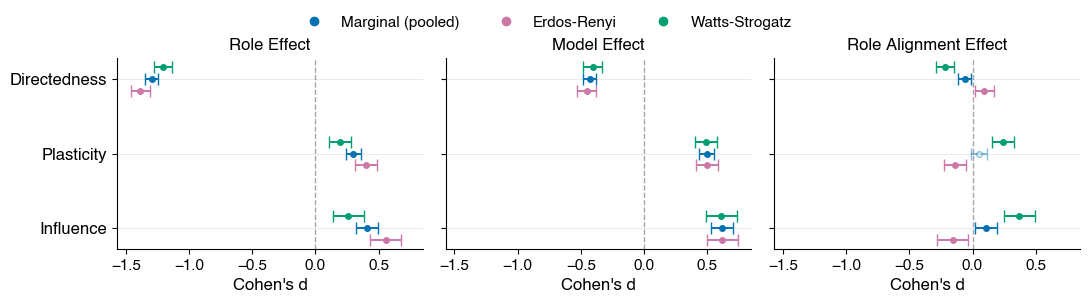

In [34]:
fig = plot_contrast_forest(
    summary,
    contrasts_order=["role_eff", "model_eff", "alignment"],
    outcomes_order=[
        "influence_out",
        # "influence_out_dir",
        "plasticity_tv",
        "monotonicity",
        # "net_uncertain",
        # "monotonicity_uncertainty",
    ],
    graph_types_order=["erdos-renyi", "watts-strogatz"],
    use_standardized=True,
    figsize=(11, 3),
)
fig.savefig(cts_path / "contrast_forest_triplet_panels.pdf", dpi=300, bbox_inches="tight")


## 3. Effect of Degrees
No analysis for the centrality, since it is not significant

In [17]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter

def get_degree_slopes(df, outcome: str, var: str = "degree_z"):
    """
    Fit setting * graph_type * degree_z model and extract per-cell degree slopes.
    Returns a dataframe with 8 rows (4 settings × 2 graph types) and the
    estimated slope of `var` within each cell.
    """
    spec = (f"{outcome} ~ setting * graph_type * {var} + "
            f"(1 | statement_id) + (1 | run_id)")
    
    with localconverter(default_converter + pandas2ri.converter):
        ro.globalenv['df_r'] = df
        ro.globalenv['spec'] = spec
        ro.globalenv['var_name'] = var
        
        ro.r('''
            library(lmerTest)
            library(emmeans)
            emm_options(pbkrtest.limit = 100000, lmerTest.limit = 100000)
            
            df_model <- lmer(as.formula(spec), data = df_r, REML = TRUE)
            
            slopes <- as.data.frame(
                emtrends(df_model, ~ setting * graph_type, var = var_name, lmer.df = "satterthwaite")
            )
        ''')
        slopes = ro.r['slopes']
    
    return slopes

In [18]:

rows = []
for col in ['influence_in', 'influence_out', 'influence_in_dir', 'influence_out_dir', 
            'monotonicity',   
            'net_change', 'net_gain',
            'progress_efficiency', 'progress_forward', 'progress_backward', 
            'plasticity_tv','plasticity_neither', 'plasticity_true', 'plasticity_false']:
    var_name = "degree_z"
    slopes = get_degree_slopes(dft, outcome=col, var=var_name)
    outcome_sd = dft[col].std()  # for standardization
    for _, row in slopes.iterrows():
        rows.append({
            'outcome': col,
            'effect_col': var_name,
            'setting': row['setting'],
            'graph_type': row['graph_type'],
            'trend': row[f'{var_name}.trend'],
            'se': row['SE'],
            'df': row['df'],
            'lower': row['lower.CL'],
            'upper': row['upper.CL'],
        })
    print(f"Finished extracting slopes for {col}")
degree_trends = pd.DataFrame(rows)
degree_trends.to_csv(con_path / "degree_trends.csv", index=False)

Finished extracting slopes for influence_in
Finished extracting slopes for influence_out
Finished extracting slopes for influence_in_dir
Finished extracting slopes for influence_out_dir
Finished extracting slopes for monotonicity
Finished extracting slopes for net_change
Finished extracting slopes for net_gain
Finished extracting slopes for progress_efficiency
Finished extracting slopes for progress_forward
Finished extracting slopes for progress_backward
Finished extracting slopes for plasticity_tv
Finished extracting slopes for plasticity_neither
Finished extracting slopes for plasticity_true
Finished extracting slopes for plasticity_false


KeyError: 'influence_in'

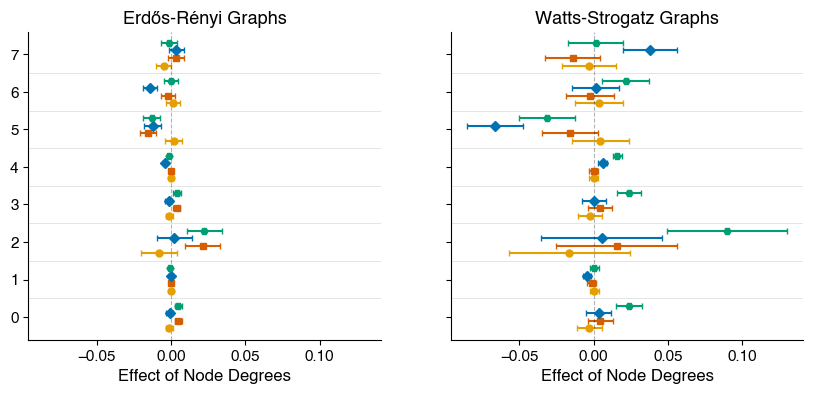

In [19]:
def plot_slope_forest(degree_trends, outcomes_order=None, figsize=(10, 4)):
    df = degree_trends.copy()
    
    if outcomes_order is None:
        outcomes_order = df['outcome'].unique().tolist()
    
    setting_order = ['base_llms', 'random_roles', 'random_experts', 'experts']
    colors = SETTING_COLOR

    
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, sharex=True)
    
    for ax, graph_type in zip(axes, ['erdos-renyi', 'watts-strogatz']):
        sub = df[df['graph_type'] == graph_type]
        labeled_settings = set()
        
        for s_idx, setting in enumerate(setting_order):
            sub_s = sub[sub['setting'] == setting]
            offset = (s_idx - 1.5) * 0.20  # spread out within each outcome row
            
            for _, row in sub_s.iterrows():
                y = outcomes_order.index(row['outcome']) + offset
                label = SETTING_MAP[setting] if setting not in labeled_settings else None
                ax.errorbar(
                    row['trend'], y,
                    xerr=[[row['trend'] - row['lower']], [row['upper'] - row['trend']]],
                    fmt=SETTING_MARKER[setting],
                    color=colors[setting], capsize=2, markersize=5,
                    label=label,
                )
                labeled_settings.add(setting)
        
        ax.axvline(0, color='k', linestyle='--', alpha=0.3, linewidth=0.8)
        for y_sep in np.arange(len(outcomes_order) - 1) + 0.5:
            ax.axhline(y_sep, color='0.85', linewidth=0.7, alpha=0.7, zorder=0)
        ax.set_ylim(-0.6, len(outcomes_order) - 0.4)
        ax.set_title(f"{GRAPH_MAP[graph_type]} Graphs", fontsize=13)
        ax.set_xlabel('Effect of Node Degrees', fontsize=12)
        ax.spines[['top', 'right']].set_visible(False)
    
    axes[0].set_yticks(range(len(outcomes_order)))
    axes[0].set_yticklabels([COL_PRETTY_NAMES[outcome] for outcome in outcomes_order])
    axes[0].legend(loc='lower left', fontsize=10, frameon=False)
    plt.tight_layout()
    return fig

cols_to_choose = [
    'influence_in', 'influence_out',
    'progress_forward',
    'plasticity_tv', 'plasticity_neither',
    'monotonicity', 'net_change','net_gain',
]

trends_filtered = degree_trends[degree_trends['outcome'].isin(
     cols_to_choose
    )]
fig = plot_slope_forest(trends_filtered, outcomes_order=cols_to_choose)

fig.savefig(con_path / "degree_slope_forest.pdf", dpi=300, bbox_inches='tight')

In [ ]:
# for col in ['influence_in', 'influence_out', 'influence_in_dir', 'influence_out_dir', 
#             'plasticity_tv', 'monotonicity', 'net_change', 'progress_forward', 'progress_backward', 'plasticity_neither']:
    
#     var_name = "degree_z"
#     slopes = get_degree_slopes(dft, outcome=col, var=var_name)
#     # print(slopes)

#     fig, ax = plt.subplots(figsize=(6, 4))
#     labels = [f"{s} ({g})" for s, g in zip(slopes['setting'], slopes['graph_type'])]
#     ax.errorbar(
#         slopes[f'{var_name}.trend'], range(len(slopes)),
#         xerr=[slopes[f'{var_name}.trend'] - slopes['lower.CL'],
#             slopes['upper.CL'] - slopes[f'{var_name}.trend']],
#         fmt='o', capsize=4
#     )
#     ax.set_yticks(range(len(slopes)))
#     ax.set_yticklabels(labels)
#     ax.axvline(0, color='k', linestyle='--', alpha=0.3)
#     ax.set_xlabel(f'Slope of {col} on {var_name}')
#     plt.tight_layout()